# Quantum accuracy from clean visibility grids (with readout)

Curves use `data/fig4_clean_m_vm_grids_nq_readout.json` for $|\alpha|=n_q$ and `data/fig4_clean_m_vm_grids_nq2_readout.json` for $|\alpha|=n_q/2$ (same pipeline as `curve_fitting/build_quantum_accuracy_from_vm_grids.py`).

2×2 layout: **rows** α = nq, nq/2; **columns** prep ε_p = 0.01 (left), 0.05 (right).  
No shading. Shared x and y axes, no spacing. Y-axis [0.5, 1].


In [1]:
import sys
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

# Repo root: when run from figures_notebooks/, go up one level
REPO_ROOT = Path.cwd().parent if Path.cwd().name == "figures_notebooks" else Path.cwd()

plt.style.use(str(REPO_ROOT / "figures_notebooks" / "single_column.mplstyle"))

sys.path.insert(0, str(REPO_ROOT / "curve_fitting"))
from build_quantum_accuracy_from_vm_grids import build_curves

# Visibility JSONs (readout included in V_mr); |α|=n_q vs n_q/2
SRC_VM_NQ = REPO_ROOT / "data" / "fig4_clean_m_vm_grids_nq_readout.json"
SRC_VM_NQ2 = REPO_ROOT / "data" / "fig4_clean_m_vm_grids_nq2_readout.json"

# Rows = alpha; columns = prep (left → right on the figure)
PREP_VALS = ["0.05", "0.01"]  # amplitudes in data / build_curves
PREP_COL_ORDER = ["0.01", "0.05"]  # column index 0 = left, 1 = right
NQ_MAX_PER_COL = [50, 50]  # same index as PREP_COL_ORDER
alpha_patterns = ["nq", "nq/2"]  # row 0, row 1
alpha_to_d_mode = {"nq": "nq", "nq/2": "nq_over_2"}
readout_by_device = {
    "I": "0.1%",
    "T": "0.1%",
    "S": "1%",
}  # must match readout labels in the VM JSON exports



Bad key axes.grid.alpha in file /Users/krzywdaja/Documents/noisy-learning-advantage-3/figures_notebooks/single_column.mplstyle, line 30 ('axes.grid.alpha   : 0.35')
You probably need to get an updated matplotlibrc file from
https://github.com/matplotlib/matplotlib/blob/v3.9.4/lib/matplotlib/mpl-data/matplotlibrc
or from the matplotlib source distribution


In [2]:
nq = None
curves = {}
for alpha_key in alpha_patterns:
    path = SRC_VM_NQ if alpha_key == "nq" else SRC_VM_NQ2
    obj = build_curves(
        path,
        d_mode=alpha_to_d_mode[alpha_key],
        amplitudes=PREP_VALS,
        nq_min=5,
        nq_max=120,
    )
    if nq is None:
        nq = np.array(obj["nq_values"])
        devices = obj["devices"]
        channels = obj["channels"]
    for device in devices:
        for channel in channels:
            for prep in PREP_VALS:
                ro = obj["device_readout_labels"][device]
                v = obj["curves"][device][channel][prep][ro]
                curves.setdefault(device, {}).setdefault(channel, {}).setdefault(alpha_key, {}).setdefault(ro, {})[
                    prep
                ] = v

# A = green, B = blue, C = red (device_display: I→A, T→B, S→C)
device_colors = {"I": "#43A047", "T": "#1565C0", "S": "#C62828"}
device_display = {"I": "A", "T": "B", "S": "C"}

channel_linestyle = {"dephasing": "-.", "depolarizing": "--", "relaxation": "-"}

LINEWIDTH = 2.0
CHANNEL_LEGEND_LW = 1.2  # thinner than data lines

# n_q above this is drawn fainter (extrapolation of the stretched-exponential fit)
NQ_EXTRAP_START = 22
EXTRAP_ALPHA = 0.38

# Proxy artists for separate legends
from matplotlib.lines import Line2D

devices_legend_order = ["I", "T", "S"]  # A, B, C
legend_devices = [
    Line2D([0], [0], color=device_colors[d], lw=LINEWIDTH, label=device_display.get(d, d))
    for d in devices_legend_order
]

channels_plot = [c for c in channels if c != "depolarizing"]
legend_channels = [
    Line2D([0], [0], color="k", ls=channel_linestyle[c], lw=CHANNEL_LEGEND_LW, label=c) for c in channels_plot
]


/var/folders/wj/x78z9z710q7csr068fhd10bxk7mx3x/T/ipykernel_47420/1070414935.py:53: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(["" if abs(y - 1.0) < 1e-6 else f"{y:g}" for y in yticks])
/var/folders/wj/x78z9z710q7csr068fhd10bxk7mx3x/T/ipykernel_47420/1070414935.py:53: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(["" if abs(y - 1.0) < 1e-6 else f"{y:g}" for y in yticks])
/var/folders/wj/x78z9z710q7csr068fhd10bxk7mx3x/T/ipykernel_47420/1070414935.py:53: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(["" if abs(y - 1.0) < 1e-6 else f"{y:g}" for y in yticks])
/var/folders/wj/x78z9z710q7csr068fhd10bxk7mx3x/T/ipykernel_47420/1070414935.py:53: UserWarning: set_ticklabels() should only be

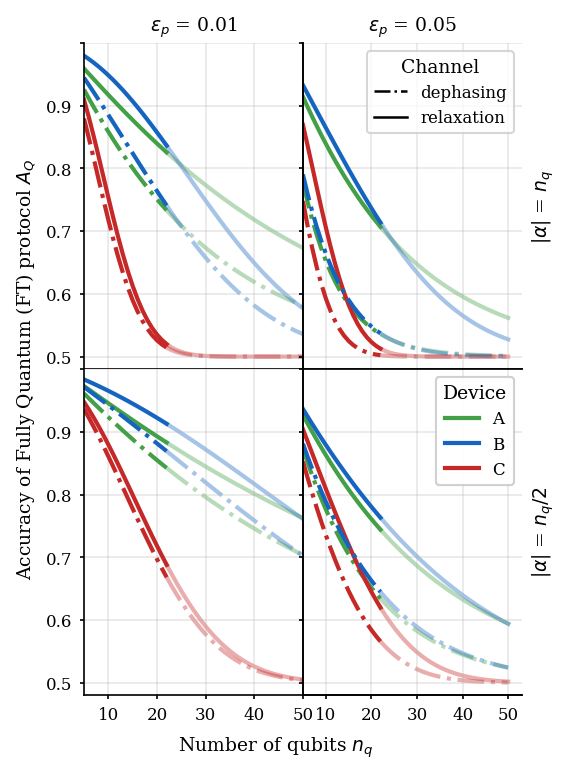

In [5]:
fig, axes = plt.subplots(
    2, 2, figsize=(4, 5), sharex="col", sharey=True,
    gridspec_kw={"hspace": 0, "wspace": 0}
)
# rows = alpha (nq, nq/2); cols = PREP_COL_ORDER (0.01 | 0.05)

for i_row, alpha_key in enumerate(alpha_patterns):
    for i_col, prep in enumerate(PREP_COL_ORDER):
        ax = axes[i_row, i_col]
        nq_max = NQ_MAX_PER_COL[i_col]
        mask = nq <= nq_max
        nq_plot = nq[mask]

        for device in devices:
            if device == "B_r0.7pct":
                continue
            color = device_colors[device]
            for channel in channels_plot:
                ls = channel_linestyle[channel]
                y = np.array(
                    curves[device][channel][alpha_key][readout_by_device[device]][prep]
                )[mask]
                trust = nq_plot <= NQ_EXTRAP_START
                extrap = nq_plot >= NQ_EXTRAP_START
                if np.any(trust):
                    ax.plot(
                        nq_plot[trust],
                        y[trust],
                        color=color,
                        ls=ls,
                        zorder=2,
                        lw=LINEWIDTH,
                        alpha=1.0,
                    )
                if np.any(extrap):
                    ax.plot(
                        nq_plot[extrap],
                        y[extrap],
                        color=color,
                        ls=ls,
                        zorder=1,
                        lw=LINEWIDTH,
                        alpha=EXTRAP_ALPHA,
                    )

        ax.set_ylim(0.48, 1)
        xmax = 42 if prep == "0.01" else 53
        ax.set_xlim(5, xmax)
        ax.set_xticks([10, 20, 30, 40, 50])
        ax.grid(True, alpha=0.3)
        # Hide y-tick label at 1.0 (no label on top of axis)
        yticks = ax.get_yticks()
        ax.set_yticklabels(["" if abs(y - 1.0) < 1e-6 else f"{y:g}" for y in yticks])
        if i_row == 0:
            ax.set_title(f"$\\epsilon_p$ = {prep}")
        if i_col == 1:
            ax2 = ax.twinx()
            ax2.set_ylabel(f"$|\\alpha|$ = $n_q/2$" if alpha_key == "nq/2" else f"$|\\alpha|$ = $n_q$")
            ax2.set_yticks([])
        # Legends stay in the ε_p = 0.05 column (right)
        if i_row == 1 and i_col == 1:
            leg_dev = ax.legend(handles=legend_devices, title="Device", loc="upper right", fontsize=8)
            ax.add_artist(leg_dev)

        if i_row == 0 and i_col == 1:
            ax.legend(handles=legend_channels, title="Channel", loc="upper right", fontsize=8)

plt.tight_layout()
fig.supxlabel("Number of qubits $n_q$", fontsize=plt.rcParams.get("axes.labelsize", 10), y=-0.02)
fig.supylabel(
    r"Accuracy of Fully Quantum (FT) protocol $A_Q$",
    fontsize=plt.rcParams.get("axes.labelsize", 10),
    x=0.065,
)
fig.subplots_adjust(left=0.18)
plt.savefig(str(REPO_ROOT / "figures_manuscript" / "fig2_quantum_acc.pdf"), bbox_inches="tight")


/var/folders/wj/x78z9z710q7csr068fhd10bxk7mx3x/T/ipykernel_98613/2223651147.py:61: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(["" if abs(yv - 1.0) < 1e-6 else f"{yv:g}" for yv in yticks])
/var/folders/wj/x78z9z710q7csr068fhd10bxk7mx3x/T/ipykernel_98613/2223651147.py:61: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(["" if abs(yv - 1.0) < 1e-6 else f"{yv:g}" for yv in yticks])
/var/folders/wj/x78z9z710q7csr068fhd10bxk7mx3x/T/ipykernel_98613/2223651147.py:61: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(["" if abs(yv - 1.0) < 1e-6 else f"{yv:g}" for yv in yticks])
/var/folders/wj/x78z9z710q7csr068fhd10bxk7mx3x/T/ipykernel_98613/2223651147.py:61: UserWarning: set_ticklabels() shoul

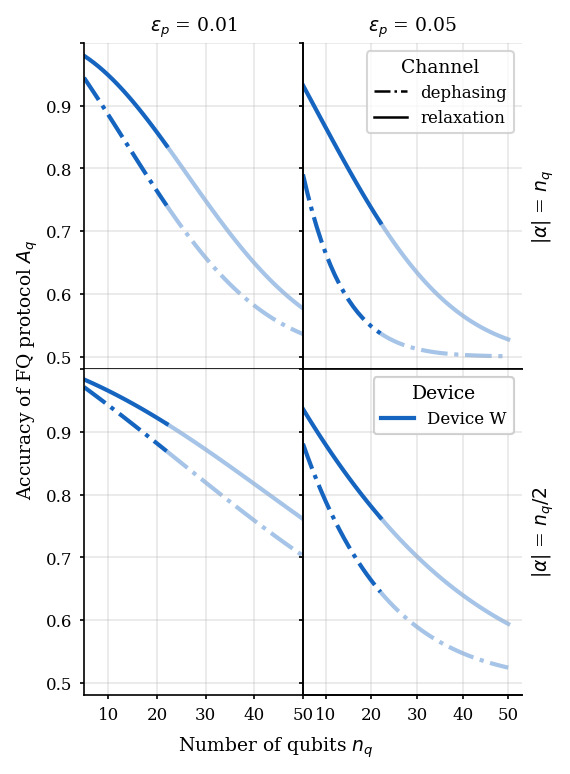

In [ ]:
# Device-only variant: keep only T (readout ~0.7%) and relabel as Device W

DEVICE_W_KEY = "T"
DEVICE_W_LABEL = "Device W"
DEVICE_W_COLOR = device_colors.get(DEVICE_W_KEY, "#1565C0")

# Use the readout label present in the loaded curves for this device
# (avoids hard-coding a string that may not match the JSON export exactly).
sample_channel = channels_plot[0]
sample_alpha = alpha_patterns[0]
DEVICE_W_READOUT = next(iter(curves[DEVICE_W_KEY][sample_channel][sample_alpha].keys()))

fig_w, axes_w = plt.subplots(
    2, 2, figsize=(4, 5), sharex="col", sharey=True,
    gridspec_kw={"hspace": 0, "wspace": 0}
)

for i_row, alpha_key in enumerate(alpha_patterns):
    for i_col, prep in enumerate(PREP_COL_ORDER):
        ax = axes_w[i_row, i_col]
        nq_max = NQ_MAX_PER_COL[i_col]
        mask = nq <= nq_max
        nq_plot = nq[mask]

        for channel in channels_plot:
            ls = channel_linestyle[channel]
            y = np.array(
                curves[DEVICE_W_KEY][channel][alpha_key][DEVICE_W_READOUT][prep]
            )[mask]

            trust = nq_plot <= NQ_EXTRAP_START
            extrap = nq_plot >= NQ_EXTRAP_START
            if np.any(trust):
                ax.plot(
                    nq_plot[trust],
                    y[trust],
                    color=DEVICE_W_COLOR,
                    ls=ls,
                    zorder=2,
                    lw=LINEWIDTH,
                    alpha=1.0,
                )
            if np.any(extrap):
                ax.plot(
                    nq_plot[extrap],
                    y[extrap],
                    color=DEVICE_W_COLOR,
                    ls=ls,
                    zorder=1,
                    lw=LINEWIDTH,
                    alpha=EXTRAP_ALPHA,
                )

        ax.set_ylim(0.48, 1)
        xmax = 42 if prep == "0.01" else 53
        ax.set_xlim(5, xmax)
        ax.set_xticks([10, 20, 30, 40, 50])
        ax.grid(True, alpha=0.3)

        yticks = ax.get_yticks()
        ax.set_yticklabels(["" if abs(yv - 1.0) < 1e-6 else f"{yv:g}" for yv in yticks])

        if i_row == 0:
            ax.set_title(f"$\\epsilon_p$ = {prep}")
        if i_col == 1:
            ax2 = ax.twinx()
            ax2.set_ylabel(f"$|\\alpha|$ = $n_q/2$" if alpha_key == "nq/2" else f"$|\\alpha|$ = $n_q$")
            ax2.set_yticks([])

        if i_row == 1 and i_col == 1:
            leg_dev_w = [
                Line2D([0], [0], color=DEVICE_W_COLOR, lw=LINEWIDTH, label=DEVICE_W_LABEL)
            ]
            leg1 = ax.legend(handles=leg_dev_w, title="Device", loc="upper right", fontsize=8)
            ax.add_artist(leg1)

        if i_row == 0 and i_col == 1:
            ax.legend(handles=legend_channels, title="Channel", loc="upper right", fontsize=8)

plt.tight_layout()
fig_w.supxlabel("Number of qubits $n_q$", fontsize=plt.rcParams.get("axes.labelsize", 10), y=-0.02)
fig_w.supylabel(
    r"Accuracy of FQ protocol $A_q$",
    fontsize=plt.rcParams.get("axes.labelsize", 10),
    x=0.065,
)
fig_w.subplots_adjust(left=0.18)
plt.savefig(str(REPO_ROOT / "figures_manuscript" / "fig2_quantum_acc_device_w.pdf"), bbox_inches="tight")
plt.show()
